In [1]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Import data
data = pd.read_csv('churn_prediction.csv')

In [3]:
# First 5 instances
data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [4]:
# Count rows and columns
data.shape

(28382, 21)

ข้อมูลทั้งหมด 28,382 แถว คอลัมที่มีค่าว่างคือ
*   gender
*   dependents
*   occupation
*   city



In [5]:
# Non-null
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  

จัดการกับค่าว่าง (Missing Values) ดังนี้

*   แทนค่าว่างในคอลัมน์ **gender** กับ **occupation** โดยระบุเป็น 'Other'
*   แทนค่าว่างในคอลัมน์ **dependents** กับ **city** ด้วยค่าฐานนิยม (Mode)
*   จัดการข้อมูลวันที่ธุรกรรมล่าสุด (**last_transaction**) ให้พร้อมสำหรับการคํานวน โดยการเปลี่ยน type เป็น datetime ทําให้มีค่า non-null ประมาณ 3000 แถว จึงลบแถวที่เป็นค่าว่าง (null/NaT) ออกไป

ดังนั้น ข้อมูลทั้งหมดเหลือจํานวน **25,159** แถว

In [6]:
data[['gender', 'occupation']] = data[['gender', 'occupation']].fillna('Other')
data[['dependents', 'city']] = data[['dependents', 'city']].fillna(data[['dependents', 'city']].mode().iloc[0])
data['last_transaction'] = pd.to_datetime(data['last_transaction'])
data = data.dropna(subset=['last_transaction'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25159 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   customer_id                     25159 non-null  int64         
 1   vintage                         25159 non-null  int64         
 2   age                             25159 non-null  int64         
 3   gender                          25159 non-null  object        
 4   dependents                      25159 non-null  float64       
 5   occupation                      25159 non-null  object        
 6   city                            25159 non-null  float64       
 7   customer_nw_category            25159 non-null  int64         
 8   branch_code                     25159 non-null  int64         
 9   current_balance                 25159 non-null  float64       
 10  previous_month_end_balance      25159 non-null  float64       
 11  average

In [7]:
# Days since last transaction (recency)
max_date = max(data['last_transaction'])
data['recency'] = max_date - data['last_transaction']
data['recency'] = data['recency'].dt.days
data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,recency
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,224
1,2,2348,35,Male,0.0,self_employed,1020.0,2,3214,5390.37,...,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,60
3,5,2329,90,Other,0.0,self_employed,1020.0,2,582,2291.91,...,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,147
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,58
5,7,1923,42,Female,0.0,self_employed,1096.0,2,1666,15202.20,...,13798.82,0.36,0.36,857.50,286.07,15719.44,15349.75,0,2019-11-01,60


In [8]:
# Copy Data
modeling_data = data.copy()

**กําจัดค่าผิดปกติ (Outliers)** โดยการทํา Quantile กําหนด Percentile ที่ 95 ลดการโดดของค่ามากเกินไป เพื่อไม่ให้ส่งผลต่อการวิเคราะห์และลดประสิทธิภาพของ K-Means

In [9]:
quantile_prevQ = modeling_data['average_monthly_balance_prevQ'].quantile(0.95)
modeling_data['average_monthly_balance_prevQ'] = modeling_data['average_monthly_balance_prevQ'].clip(upper=quantile_prevQ)
quantile_debit = modeling_data['current_month_debit'].quantile(0.95)
modeling_data['current_month_debit'] = modeling_data['current_month_debit'].clip(upper=quantile_debit)

print(f"average_monthly_balance_prevQ: {quantile_prevQ}")
print(f"current_month_debit: {quantile_debit}")

average_monthly_balance_prevQ: 21507.77399999999
current_month_debit: 13476.165999999977


**ปรับมาตรฐานข้อมูล (Standardization)** เพราะข้อมูลแต่ละคอมลัมน์มีช่วงของค่าที่ต่างกัน จึงปรับให้มีความสําคัญเท่าเทียมกัน ป้องกันการเกิดข้อผิดพลาดในการจัดกลุ่มข้อมูล

In [10]:
# Scale data
features = modeling_data[['vintage', 'age', 'average_monthly_balance_prevQ', 'current_month_debit', 'recency']]
scaler = StandardScaler()
scaler_features = scaler.fit_transform(features)

**หาจำนวนกลุ่ม (K)** ที่เหมาะสมที่สุด โดยพิจารณาจากจุดที่ค่าความผิดเพี้ยน (WCSS) เริ่มลดลงอย่างคงที่ ซึ่งในโปรเจกต์นี้เลือกแบ่งเป็น 6 กลุ่ม

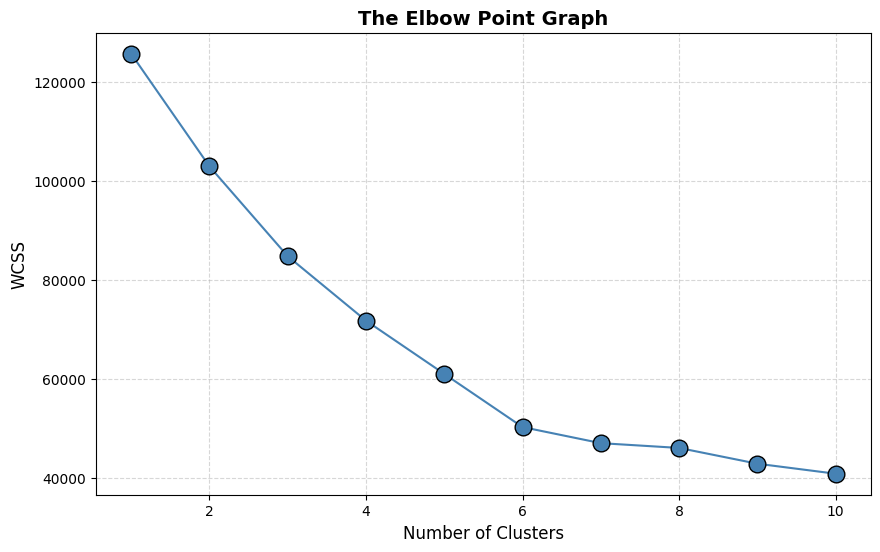

In [11]:
WCSS = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(scaler_features)
  WCSS.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11), WCSS, marker='o', markersize=12, color='steelblue', mec='black')
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('The Elbow Point Graph', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.show()

In [12]:
# Model Fitting
model = KMeans(n_clusters=6, init="k-means++", random_state=42)
y_kmeans = model.fit(scaler_features)

In [13]:
# Assign cluster labels to the dataframe
modeling_data['cluster'] = model.labels_+1
modeling_data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction,recency,cluster
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21,224,3
1,2,2348,35,Male,0.0,self_employed,1020.0,2,3214,5390.37,...,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01,60,1
3,5,2329,90,Other,0.0,self_employed,1020.0,2,582,2291.91,...,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06,147,2
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03,58,5
5,7,1923,42,Female,0.0,self_employed,1096.0,2,1666,15202.20,...,0.36,0.36,857.50,286.07,15719.44,15349.75,0,2019-11-01,60,6


นําข้อมูลของ vintage, age, average_monthly_balance_prevQ, current_month_debit และ recency มาแบ่งกลุ่ม และหาค่าเฉลี่ย เพื่อดูภาพรวม

In [14]:
grouped = modeling_data.groupby('cluster')[['vintage', 'age', 'average_monthly_balance_prevQ', 'current_month_debit', 'recency']].mean()
print(grouped)

             vintage        age  average_monthly_balance_prevQ  \
cluster                                                          
1        2200.491064  36.697682                    3826.513970   
2        2172.008743  67.711682                    4120.036652   
3        2130.466746  46.277910                    4312.508554   
4        2104.250463  50.500463                    8827.054503   
5        1618.282332  45.199467                    4245.518116   
6        2115.642760  52.452565                   18149.485802   

         current_month_debit     recency  
cluster                                   
1                 910.722315   39.061340  
2                 778.868454   43.150112  
3                 345.665817  249.755344  
4               11865.234834   22.722222  
5                 934.563151   50.266055  
6                1192.019060   59.108488  


**Grouped Bar Chart** วิเคราะห์ความสัมพันธ์ระหว่างจํานวนเงิน และการใช้งานจริงของลูกค้าในแต่ละกลุ่ม โดยใช้ 2 ตัวแปร คือ

*   **Average Monthly Balance:** ยอดเงินคงเหลือเฉลี่ยในบัญชีจากไตรมาสที่ผ่านมา ซึ่งเป็นตัวบ่งชี้สภาพคล่องของลูกค้า
*   **Current Month Debit:** ยอดรวมการใช้งานหรือการจ่ายเงินออกจากบัญชีในเดือนล่าสุด ซึ่งสะท้อนถึงพฤติกรรมการใช้จ่ายจริง

**จากการวิเคราะห์**

*   กลุ่มที่มี Balance สูง แต่ Debit ต่ำ เช่น กลุ่มที่ 6  เป็นกลุ่มลูกค้าที่มีศักยภาพทางการเงินสูง แต่ยังมีการใช้งานบัตรน้อย

*  กลุ่มที่มี Debit สูง แต่ Balance ต่ำ เช่น กลุ่มที่ 4 เป็นกลุ่มลูกค้าที่เน้นการใช้งานจริง แม้จะมีเงินในบัญชีไม่มาก แต่มีการหมุนเวียนของเงินสูง

*   กลุ่มที่มีค่าต่ำทั้งสองด้าน เช่น กลุ่มที่ 1, 2, 3 และ 5 อาจเป็นกลุ่มลูกค้าที่เริ่มหยุดนิ่ง







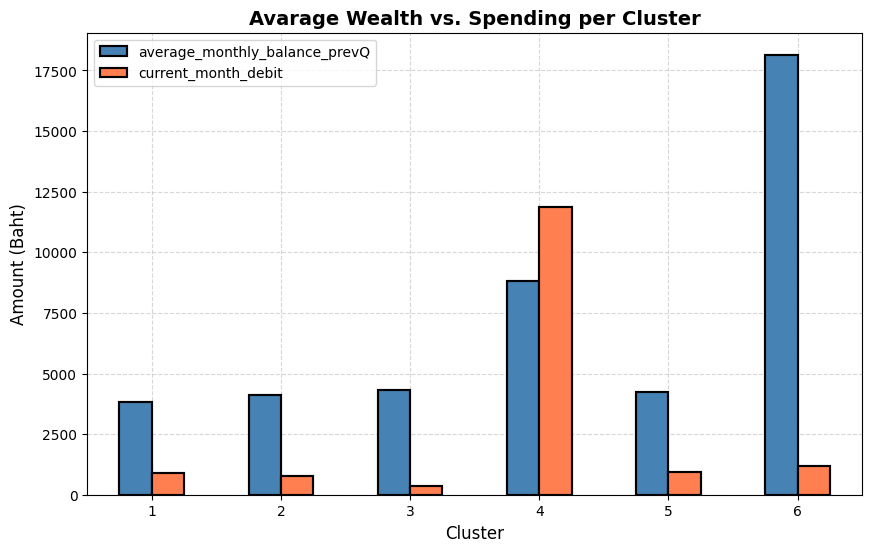

In [15]:
ax_bar = grouped[['average_monthly_balance_prevQ', 'current_month_debit']].plot(
    kind='bar',
    linewidth=1.55,
    figsize=(10, 6),
    edgecolor='black',
    color=['steelblue', 'coral']
)

ax_bar.set_axisbelow(True)
plt.title('Avarage Wealth vs. Spending per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Amount (Baht)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.show()

**Scatter Plot** วิเคราะห์ความสัมพันธ์ระหว่างระยะเวลาที่ลูกค้าอยู่กับธนาคารและความต่อเนื่องในการใช้งาน

*   **Average Vintage (แกน X)** : แสดงจํานวนวันที่ลูกค้าใช้งาน ถ้าค่ามากแสดงว่าเป็นลูกค้าอยู่กับธนาคารมานาน

*   **Average Recency (แกน Y)** : แสดงจํานวนการหยุดใช้งาน ถ้าค่าน้อยแสดงว่าเพิ่งมีการใช้งาน แต่ถ้าค่าสูงแสดงว่าหยุดใช้งานไปนาน

**จากการวิเคราะห์**

*   Vintage สูง และ Recency ต่ำ เช่น กลุ่มที่ 1, 2, 4 และ 6 คือกลุ่มลูกค้าที่ใช้งานมานาน และยังใช้งานสม่ำเสมอ

*   มี Vintage ต่ำ และ Recency ต่ำ เช่น กลุ่มที่ 5 คือลูกค้าใหม่ที่เพิ่งเริ่มใช้งาน

*   มี Vintage สูง และ Recency สูง เช่น กลุ่มที่ 3 คือกลุ่มลูกค้าที่ใช้งานมานาน และแต่ไม่ได้ใช้งานมานาน




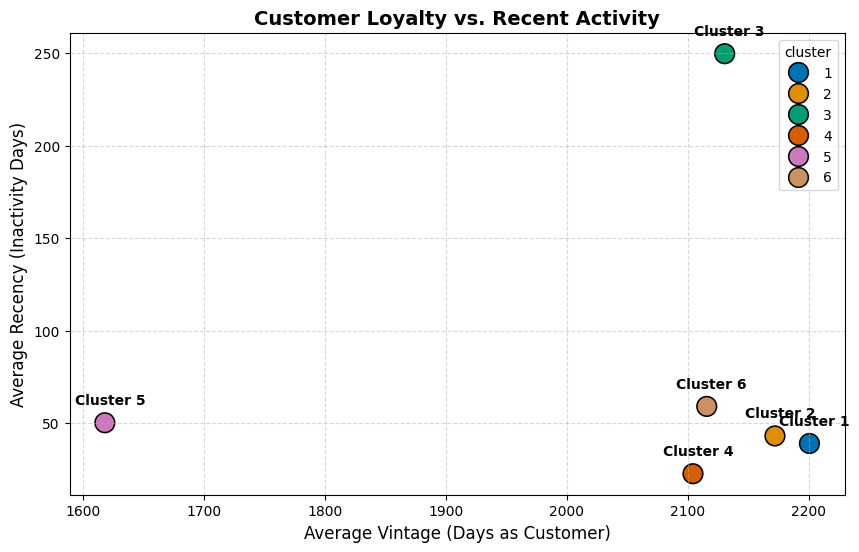

In [16]:
plt.figure(figsize=(10,6))
ax_scotter = sns.scatterplot(
    x='vintage',
    y='recency',
    hue='cluster',
    data=grouped,
    palette='colorblind',
    s=200,
    edgecolor='black'
)

for i in range(len(grouped)):
  plt.text(
      grouped.vintage.iloc[i]-25,
      grouped.recency.iloc[i]+10,
      f'Cluster {grouped.index[i]}',
      fontsize=10,
      fontweight='bold'
  )

plt.title('Customer Loyalty vs. Recent Activity', fontsize=14, fontweight='bold')
plt.xlabel('Average Vintage (Days as Customer)', fontsize=12)
plt.ylabel('Average Recency (Inactivity Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Heatmap** เพื่อเปรียบเทียบ **จุดเด่น** และ **จุดด้อย** ของแต่ละกลุ่มลูกค้าเทียบกับค่าเฉลี่ยข้อมูล

เนื่องจากข้อมูลแต่ละคอลัมน์มีหน่วย และขนาดที่แตกต่างกัน ซึ่งส่งผลให้เกิดข้อผิดพลาดขอการทํา Heatmap จึงมีการทำ *Normalization* ปรับค่าให้อยู่ในช่วง 0 ถึง 1 เพื่อให้สามารถเปรียบเทียบได้

**จากการวิเคราะห์**

*   Vintage
     - สีเข้ม หมายถึง ลูกค้าที่ใช้งานมานาน
     - สีอ่อน หมายถึง ลูกค้าใหม่

*   Age
     - สีเข้ม หมายถึง ลูกค้าที่มีอายุเยอะ
     - สีอ่อน หมายถึง ลูกค้าที่มีอายุน้อย

*   Average Monthly Balance PrevQ
     - สีเข้ม หมายถึง ลูกค้าที่มีสภาพคล่องสูง
     - สีอ่อน หมายถึง ลูกค้าทั่วไป

*   Current Month Debit
     - สีเข้ม หมายถึง ลูกค้าที่ใช้บัตรหรือบัญชีเป็นหลักในชีวิตประจำวัน
     - สีอ่อน หมายถึง ลูกค้าที่ถือบัญชีไว้เฉยๆ หรือใช้เป็นบัญชีเงินออมอย่างเดียว

*   Recency
     - สีเข้ม หมายถึง ลูกค้าที่เลิกใช้งานไปนาน
     - สีอ่อน หมายถึง ลูกค้าที่เพิ่งมีการเคลื่อนไหวไม่นานมานี้


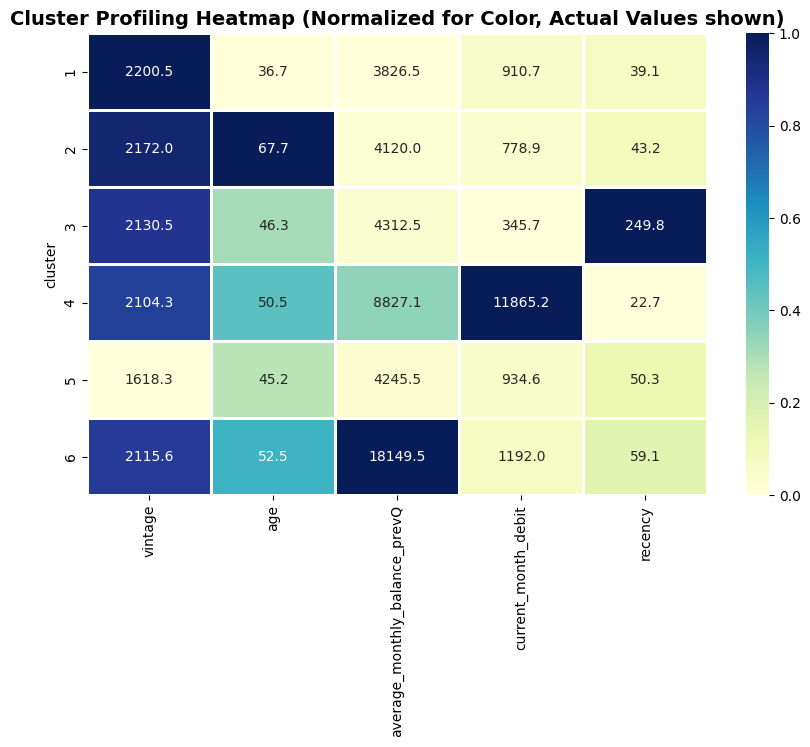

In [17]:
grouped_normalized = ((grouped - grouped.min()) / (grouped.max() - grouped.min()))

plt.figure(figsize=(10,6))
sns.heatmap(data=grouped_normalized, annot=grouped, fmt='.1f', cmap='YlGnBu', linewidths=1)

plt.title('Cluster Profiling Heatmap (Normalized for Color, Actual Values shown)', fontsize=14, fontweight='bold')
plt.show()

***สรุป***

* **Cluster 1**: เป็นกลุ่มที่มีอายุเฉลี่ยตํ่าที่สุด มีระยะเวลาในการใช้มานานที่สุด และยังมีการใช้งานอยู่ในปัจจุบัน

* **Cluster 2**: เป็นกลุ่มที่มีอายุเฉลี่ยสูงที่สุด มีระยะเวลาในการใช้มานาน และยังมีการใช้งานอยู่ในปัจจุบัน

* **Cluster 3**: เป็นกลุ่มที่เลิกใช้งานไปนานที่สุด ทั้งที่มีประวัติการใช้งาน (vintage) ค่อนข้างนาน

* **Cluster 4**: เป็นกลุ่มที่มีการใช้บัญชีสมํ่าเสมอที่สุด และยังใช้งานอยู่ในปัจจุบัน

* **Cluster 5**: เป็นกลุ่มที่มีประวัติการใช้งาน (vintage) น้อยที่สุด แต่ยังมีการใช้งานบัญชีสมํ่าเสมอ และใช้อยู่ในปัจจุบัน

* **Cluster 6**: เป็นกลุ่มที่มีการใช้งานธนาคารมานาน เงินคงเหลือในบัญชีค่อนข้างสูง มีการใช้งานบัญชีอยู่บ้าง และใช้มาจนถึงปัจจุบัน
